In [3]:
import numpy as np
import librosa as lb
import os
from pathlib import Path
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

In [4]:
%%capture
%run ./DTW.ipynb
%run ./schumann_testing.ipynb

Analyzing DTW for specific Measures:

In [82]:
def compare_measures_mod(midi_file, xml_file, xml_measure_frames, midi_measure_frames, epsilon, start_measure=None, end_measure=None):
    
    F1data = np.load(midi_file) # 88 x N
    F1 = F1data['roll']
    F2data = np.load(xml_file) # 88 x M
    F2 = F2data['roll']

    lxml = len(xml_measure_frames)
    lmidi = len(midi_measure_frames)
    soft_accuracy = []
    count = 0
    total_frames = 0

    for i in range(max(lxml, lmidi) - 1):
        current_measure = i + 1
        if start_measure is not None and current_measure < start_measure:
            continue
        if end_measure is not None and current_measure > end_measure:
            continue
        if i >= lxml - 1 or i >= lmidi - 1:
            break

        ################################################################
        
        # # get one midi frame
        # midi_frame = F1[:, midi_measure_frames[i][1]].reshape(1, -1)
        
        # # collapse epsilon window of xml frames
        # xml_start = max(0, int(xml_measure_frames[i]) - epsilon)
        # xml_end = min(F2.shape[1], int(xml_measure_frames[i]) + epsilon + 1)
        # xml_comb = np.any(F2[:, xml_start:xml_end], axis=1).reshape(1, -1)
        
        # # jaccard between single midi and collapsed frame
        # jaccard = cdist(midi_frame, xml_comb, metric='jaccard')[0][0]
        
        ################################################################

        # get epsilon window of frames for midi
        midi_start = max(0, int(midi_measure_frames[i]) - epsilon)
        midi_end = min(F1.shape[1], int(midi_measure_frames[i]) + epsilon + 1)
        
        # get one xml frame
        xml_frame = F2[:, xml_measure_frames[i]].reshape(1, -1)
        
        # compare midi frame with xml window to find best match
        best_jaccard = 1
        for midi_idx in range(midi_start, midi_end):
            midi_frame = F1[:, midi_idx].reshape(1, -1)
            current_jaccard = cdist(xml_frame, midi_frame, metric='jaccard')[0][0]
            best_jaccard = min(best_jaccard, current_jaccard)
        
        jaccard = best_jaccard
        ################################################################


        soft_accuracy.append(1 - jaccard)
        total_frames += 1

        if jaccard == 0:
            count += 1

    if total_frames > 0:
        strict_accuracy = 100 * count / total_frames
        soft_accuracy = np.mean(soft_accuracy) * 100
        
    return strict_accuracy, soft_accuracy

In [164]:
def dtw_for_diff_epsilons(featfile1, featfile2, epsilon_vals):
    """
    single pair of midi and xml files with multiple epsilon values
    """

    # DTW params
    steps = np.array([1,0,0,1,1,1]).reshape((-1,2))
    weights = np.array([1,1,2])
    downsample = 1

    wp, C = alignDTW(featfile1, featfile2, steps, weights, downsample)
    
    # get measure boundaries
    xml_data = np.load(featfile2)
    measure_boundaries = xml_data['measure_boundaries']
    
    # get midi measure frames
    midi_measure_frames = midi_measure(measure_boundaries, wp)

    midi_measure_frames = [x[1] for x in midi_measure_frames]
    
    results = {}
    for epsilon in epsilon_vals:
        strict_acc, soft_acc = compare_measures_mod(featfile1, featfile2, measure_boundaries, midi_measure_frames, epsilon)
        results[epsilon] = (strict_acc, soft_acc)
    return results
        
def batch_compare_measures(songlist, featdir1, featdir2, outfile_prefix, epsilon_vals):
    """
    compare measures for a batch of songs with multiple epsilon values
    """
    featdir1 = Path(featdir1)
    featdir2 = Path(featdir2)
    outfile_prefix = Path(outfile_prefix)
    outfile_prefix.parent.mkdir(parents=True, exist_ok=True)
     
    # prep input pairs
    inputs = []
    songpairs = []
    with open(songlist, 'r') as f:
        for line in f:
            parts = line.strip().split(' ')
            assert len(parts) == 2

            featfile1 = (featdir1 / (parts[0] + '.mid')).with_suffix('.npz')
            featfile2 = (featdir2 / (parts[1] + '.musicxml')).with_suffix('.npz')

            queryid = os.path.basename(parts[0]) + '__' + os.path.basename(parts[1])
            
            inputs.append((featfile1, featfile2, epsilon_vals))
            songpairs.append(queryid)
   
    # process all songs
    all_results = {}
    for epsilon in epsilon_vals:
        all_results[epsilon] = {'strict_accuracies': [], 'soft_accuracies': []}
    
    for input_args in inputs:
        result = dtw_for_diff_epsilons(*input_args)
        
        # get results
        for epsilon, (strict_acc, soft_acc) in result.items():
            all_results[epsilon]['strict_accuracies'].append(strict_acc)
            all_results[epsilon]['soft_accuracies'].append(soft_acc)
    
    for epsilon in epsilon_vals:
        output_file = f"{outfile_prefix}_e{epsilon}.npz"
        strict_accs = np.array(all_results[epsilon]['strict_accuracies'])
        soft_accs = np.array(all_results[epsilon]['soft_accuracies'])
        
        np.savez(output_file, strict_accuracies=strict_accs, soft_accuracies=soft_accs, epsilon=epsilon,songpairs=np.array(songpairs))

In [160]:
def plot_epsilon(outfile_prefix, epsilon_vals):

    strict_means = []
    soft_means = []
    
    # calc means for accuracies
    for epsilon in epsilon_vals:
        result_file = f"{outfile_prefix}_e{epsilon}.npz"
        if os.path.exists(result_file):
            data = np.load(result_file)
            strict_accuracies = data['strict_accuracies']
            soft_accuracies = data['soft_accuracies']
            
            strict_means.append(np.mean(strict_accuracies))
            soft_means.append(np.mean(soft_accuracies))

    plt.figure(figsize=(8, 6))
    
    # Create bars 
    bar_width = 0.35
    x = np.arange(len(epsilon_vals))
    plt.bar(x - bar_width/2, strict_means, bar_width, label='Strict Accuracy', 
            color='#27923e', alpha=0.8)
    plt.bar(x + bar_width/2, soft_means, bar_width, label='Soft Accuracy', 
            color='#4bb9a0', alpha=0.8)
    
    # labels
    plt.xlabel('Epsilon Value', fontsize=12)
    plt.ylabel('Mean Accuracy (%)', fontsize=12)
    plt.title('Effect of Epsilon Value on Alignment Accuracy', fontsize=12)
    plt.xticks(x, epsilon_vals)
    plt.ylim([0,100])
    plt.legend(fontsize=12, loc=[0,0])  

In [85]:
songlist = "normal_binary_roll"
featdir1 = "midi_features"
featdir2 = "xml_features"
outfile_prefix = "normal_binary_roll_testing"
epsilon_vals = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

batch_compare_measures(songlist=songlist, featdir1=featdir1, featdir2=featdir2, outfile_prefix=outfile_prefix, epsilon_vals=epsilon_vals)

(88, 1914)
(88, 1728)
(88, 3523)
(88, 3248)
(88, 6336)
(88, 5968)
(88, 17035)
(88, 16896)
(88, 7666)
(88, 7776)
(88, 5003)
(88, 4864)
(88, 4408)
(88, 4296)
(88, 6364)
(88, 6208)
(88, 12454)
(88, 12160)
(88, 7210)
(88, 7232)
(88, 6204)
(88, 6048)
(88, 8310)
(88, 8212)


In [86]:
songlist = "onset_binary_roll.txt"
featdir1 = "onset_midi_features"
featdir2 = "onset_xml_features"
outfile_prefix = "onset_binary_roll_testing"
epsilon_vals = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

batch_compare_measures(songlist=songlist, featdir1=featdir1, featdir2=featdir2, outfile_prefix=outfile_prefix, epsilon_vals=epsilon_vals)

(88, 1914)
(88, 1728)
(88, 3523)
(88, 3248)
(88, 6336)
(88, 5968)
(88, 17035)
(88, 16896)
(88, 7666)
(88, 7776)
(88, 5003)
(88, 4864)
(88, 4408)
(88, 4296)
(88, 6364)
(88, 6208)
(88, 12454)
(88, 12160)
(88, 7210)
(88, 7232)
(88, 6204)
(88, 6048)
(88, 8310)
(88, 8212)


In [165]:
songlist = "unique_binary_roll.txt"
featdir1 = "midi_features"
featdir2 = "unique_xml_features"
outfile_prefix = "unique_binary_roll_testing"
epsilon_vals = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

batch_compare_measures(songlist=songlist, featdir1=featdir1, featdir2=featdir2, outfile_prefix=outfile_prefix, epsilon_vals=epsilon_vals)

(88, 1914)
(88, 370)
(88, 3523)
(88, 811)
(88, 6336)
(88, 883)
(88, 17035)
(88, 1671)
(88, 7666)
(88, 1035)
(88, 5003)
(88, 910)
(88, 4408)
(88, 991)
(88, 6364)
(88, 2109)
(88, 12454)
(88, 1703)
(88, 7210)
(88, 1404)
(88, 6204)
(88, 1855)
(88, 8310)
(88, 1402)


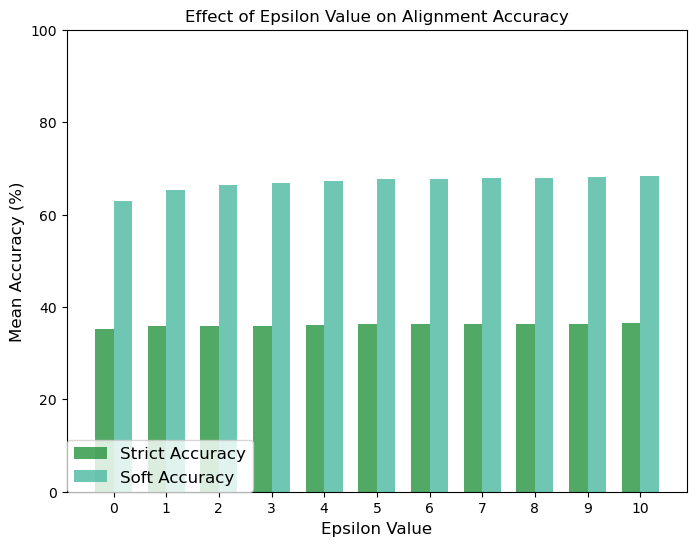

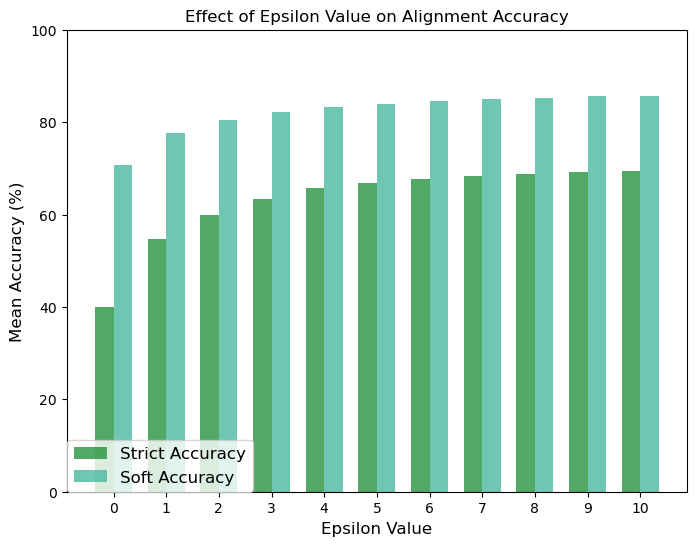

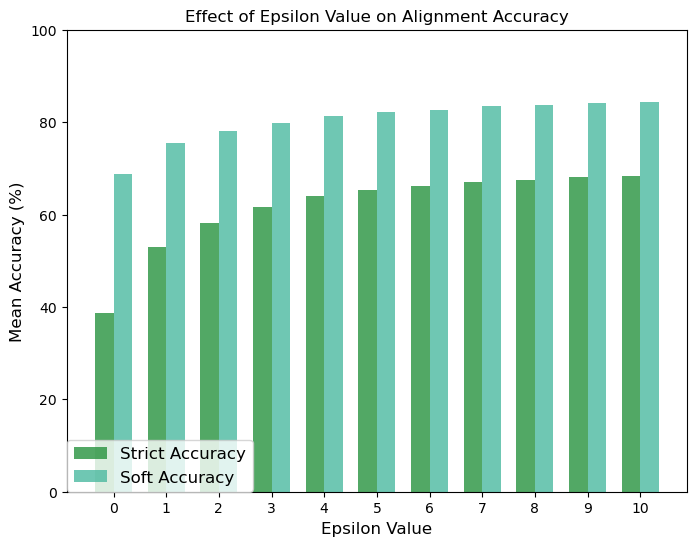

In [161]:
epsilon_vals = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_epsilon("onset_binary_roll_testing", epsilon_vals=epsilon_vals)
plot_epsilon("normal_binary_roll_testing", epsilon_vals=epsilon_vals)
plot_epsilon("unique_binary_roll_testing", epsilon_vals=epsilon_vals)

plt.show()

In [ ]:
def plot_all_epsilon(outfile_prefix, onset_outfile_prefix, unique_outfile_prefix, epsilon_vals):

    strict_means = []
    soft_means = []
    onset_strict_means = []
    onset_soft_means = []
    unique_strict_means = []
    unique_soft_means = []

    # calc means for accuracies
    for epsilon in epsilon_vals:
        result_file = f"{outfile_prefix}_e{epsilon}.npz"
        onset_result_file = f"{onset_outfile_prefix}_e{epsilon}.npz"
        unique_result_file = f"{unique_outfile_prefix}_e{epsilon}.npz"
        
        if os.path.exists(result_file):
            data = np.load(result_file)
            onset_data = np.load(onset_result_file)
            unique_data = np.load(unique_result_file)
            
            strict_accuracies = data['strict_accuracies']
            soft_accuracies = data['soft_accuracies']
            onset_strict_accuracies = onset_data['strict_accuracies']
            onset_soft_accuracies = onset_data['soft_accuracies']
            unique_strict_accuracies = unique_data['strict_accuracies']
            unique_soft_accuracies = unique_data['soft_accuracies']
            
            strict_means.append(np.mean(strict_accuracies))
            soft_means.append(np.mean(soft_accuracies))
            onset_strict_means.append(np.mean(onset_strict_accuracies))
            onset_soft_means.append(np.mean(onset_soft_accuracies))
            unique_strict_means.append(np.mean(unique_strict_accuracies))
            unique_soft_means.append(np.mean(unique_soft_accuracies))

    plt.figure(figsize=(9, 6))
    
    # Create bars 
    bar_width = 0.3
    x = np.arange(0, len(epsilon_vals) * 2.5, 2.5)
    plt.bar(x - bar_width*3, soft_means, bar_width, label='Soft Similitude', 
            color='#23acf2', alpha=0.8)
    plt.bar(x - bar_width*2, unique_soft_means, bar_width, label='Soft Similitude - unique', 
            color='#f2c933', alpha=0.8)
    plt.bar(x - bar_width*1, onset_soft_means, bar_width, label='Soft Similitude - onset', 
            color='#f478d6', alpha=0.8)
    
    plt.bar(x + bar_width*1, strict_means, bar_width, label='Strict Similitude', 
            color='#2d23f2', alpha=0.8)
    plt.bar(x + bar_width*2, unique_strict_means, bar_width, label='Strict Accuracy - unique', 
            color='#d36700', alpha=0.8)
    plt.bar(x + bar_width*3, onset_strict_means, bar_width, label='Strict Similitude - onset', 
            color='#c18dec', alpha=0.8)
    
    
    
    
    # labels
    plt.xlabel('Epsilon Value', fontsize=12)
    plt.ylabel('Mean Similitude (%)', fontsize=12)
#     plt.title('Effect of Epsilon Value on Alignment Similitude', fontsize=12)
    plt.xticks(x, epsilon_vals)
    plt.ylim([0,100])
    plt.legend(ncol=2,fontsize=12, loc=[0,0])
    plt.show()

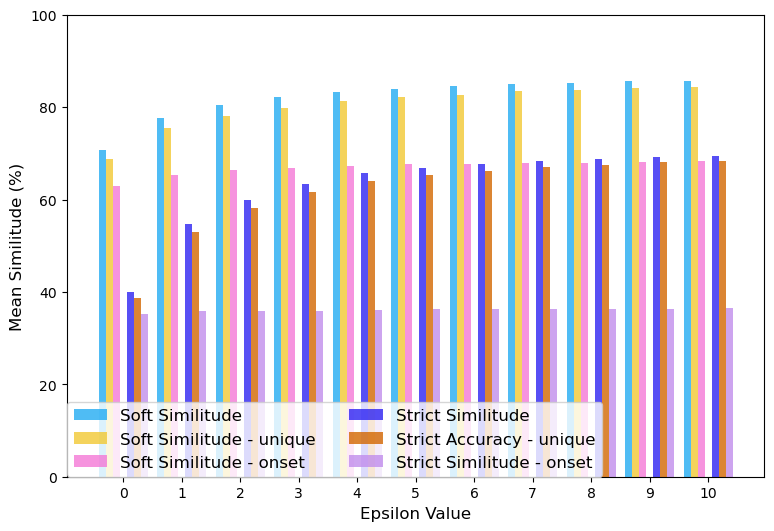

In [251]:
epsilon_vals = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
plot_all_epsilon('normal_binary_roll_testing', 'onset_binary_roll_testing', 'unique_binary_roll_testing', epsilon_vals=epsilon_vals)

In [5]:
def plot_all_pieces(outfile_prefix, onset_outfile_prefix, epsilon):


    result_file = f"{outfile_prefix}_e{epsilon}.npz"
    onset_result_file = f"{onset_outfile_prefix}_e{epsilon}.npz"
    
    if os.path.exists(result_file):
        data = np.load(result_file)
        onset_data = np.load(onset_result_file)


        strict_accuracies = data['strict_accuracies']
        soft_accuracies = data['soft_accuracies']
        onset_strict_accuracies = onset_data['strict_accuracies']
        onset_soft_accuracies = onset_data['soft_accuracies']

    pieces = ['Bach', 'Beethoven', 'Brahms', 'Chopin', 'Debussy', 'Glinka', 'Haydn', 'Liszt', 'Mozart', 'Prokofiev', 'Ravel', 'Schumann']

    metrics = {
    'Soft Similitude': soft_accuracies,
    'Soft Similitude - onset': onset_soft_accuracies,
    'Strict Similitude': strict_accuracies,
    'Strict Similitude - onset': onset_strict_accuracies
    }

    colors = {
    'Strict Similitude': '#2d23f2',
    'Soft Similitude': '#23acf2',
    'Strict Similitude - onset': '#c18dec',
    'Soft Similitude - onset': '#f478d6'
    }

    print(soft_accuracies)
            

    x = np.arange(0, len(pieces) * 2, 2)  # the label locations
    width = 0.35  # the width of the bars
    multiplier = 0

    fig, ax = plt.subplots(figsize=(7, 5))
    fig.subplots_adjust(top=0.80)

    for metric, score in metrics.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, score, width, label=metric, color=colors[metric])
        # ax.bar_label(rects, padding=3)
        multiplier += 1

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Similitude (%)')
    ax.set_xlabel('Piece')
    # ax.set_title('Similitude of Sheet Music Follower for Different Pieces', pad=60)
    ax.set_xticks(x + width*1.5, pieces)
    ax.tick_params(axis='x', labelrotation=90)
    ax.legend(ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.17))
    ax.set_ylim(0, 100)

    plt.show()

[97.11538462 90.1104039  92.07469278 79.71633774 83.19284235 87.61269841
 85.32338308 80.69444444 53.23003275 91.96455026 73.74662276 92.80412946]


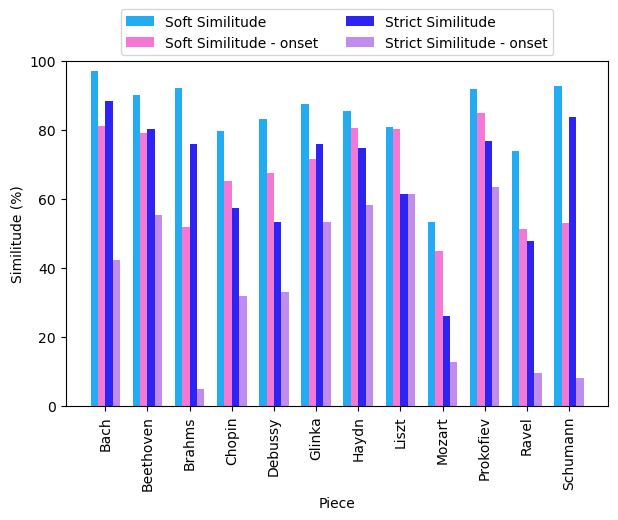

In [6]:
plot_all_pieces('normal_binary_roll_testing', 'onset_binary_roll_testing', epsilon=5)

In [7]:
# featfile1 = 'midi_features/bach_fugue_bwv_846.mid.npz'
# featfile2 = 'xml_features/bach_fugue_bwv_846.musicxml.npz' 

# featfile1 = 'midi_features/Beethoven-Chen.mid.npz'
# featfile2 = 'xml_features/Beethovem-30-1.musicxml.npz' 

# featfile1 = 'midi_features/Chopin-LeeKoeun.mid.npz'
# featfile2 = 'xml_features/Chopin-Ballades-1.musicxml.npz' 

# featfile1 = 'midi_features/debussy.mid.npz'
# featfile2 = 'xml_features/debussy.musicxml.npz' 

# featfile1 = 'midi_features/glinka.mid.npz'
# featfile2 = 'xml_features/glinka.musicxml.npz' 

# featfile1 = 'midi_features/Haydn-6-1.mid.npz'
# featfile2 = 'xml_features/Haydn-6-1.musicxml.npz' 

# featfile1 = 'midi_features/liszt_concert_etude_s145_Kleisen03.mid.npz'
# featfile2 = 'xml_features/liszt_concert_etude_s145_1.musicxml.npz' 

# featfile1 = 'midi_features/Prokofiev-Toccata.mid.npz'
# featfile2 = 'xml_features/Prokofiev-Toccata.musicxml.npz'

# featfile1 = 'midi_features/schumann_arabeske_park.mid.npz'
# featfile2 = 'xml_features/schumann_arabeske.musicxml.npz' 

In [8]:
# steps = np.array([1,0,0,1,1,1]).reshape((-1,2))
# weights = np.array([1,1,2])
# downsample = 1
# wp, C = alignDTW(featfile1, featfile2, steps, weights, downsample)

In [9]:
# xml_data = np.load(featfile2)
# measure_boundaries = xml_data['measure_boundaries']
# midi_data = np.load(featfile1)
# midi_measure_frames = midi_measure(measure_boundaries, wp)

In [10]:
# compare_alignment(featfile1, featfile2, wp, epsilon = 5)
# compare_measures_mod(featfile1, featfile2, measure_boundaries, midi_measure_frames, epsilon = 0)

In [11]:
# hyperparam = 2
# downsample = 1
# wp2 , C2  = alignMDTW_Numba(featfile1, featfile2, hyperparam, downsample)

In [12]:
# midi_measure_frames2 = midi_measure(measure_boundaries, wp2)
# compare_alignment_mod(featfile1, featfile2, wp2)
# compare_measures_mod(featfile1, featfile2, measure_boundaries, midi_measure_frames2)